In [6]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.7/126.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.

In [1]:
from google.colab import userdata

In [2]:
!git clone https://{userdata.get('TokenGithub')}"@github.com/amigli/Q-Bert_RL.git"

fatal: destination path 'Q-Bert_RL' already exists and is not an empty directory.


In [3]:
%cd Q-Bert_RL/

/content/Q-Bert_RL


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
directory_videos = '/content/Videos/'

## Algoritmo

In [6]:
from Algorithms.QBertAgent_SARSA import SARSAAgent
import gymnasium as gym
import ale_py
from tqdm import tqdm
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
from EnvironmentWrappers.QbertObservationWrapper import QbertObservationWrapperTuple
from EnvironmentWrappers.RewardFunction import RewardFunction
from EnvironmentWrappers.ObsRewardWrapper import ObsRewardWrapper

In [7]:
gym.register_envs(ale_py)

In [8]:
# hyperparameters
learning_rate = 0.01
n_episodes = 100
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

### Training

In [9]:
env = gym.make("ALE/Qbert-ram-v5")
env =  ObsRewardWrapper(env)
env = RecordEpisodeStatistics(env, buffer_length=n_episodes)
agent = SARSAAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [10]:
rewards = []

In [11]:
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False
    obs = tuple(obs)
    # print("Episode:" + str(episode))
    total_reward = 0
    action = agent.get_action(obs, True)

    while not done:
        # print(action)
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_obs = tuple(next_obs)
        # print("Reward: " + str(reward))
        # print("action: " + str(action))
        next_action = agent.get_action(next_obs, True)
        total_reward += reward
        # update the agent
        agent.update(obs, action, reward, terminated, next_obs, next_action)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs
        action = next_action

    agent.decay_epsilon()

  8%|▊         | 8/100 [00:02<00:28,  3.18it/s]

Scontro con avversario 1


100%|██████████| 100/100 [00:42<00:00,  2.37it/s]


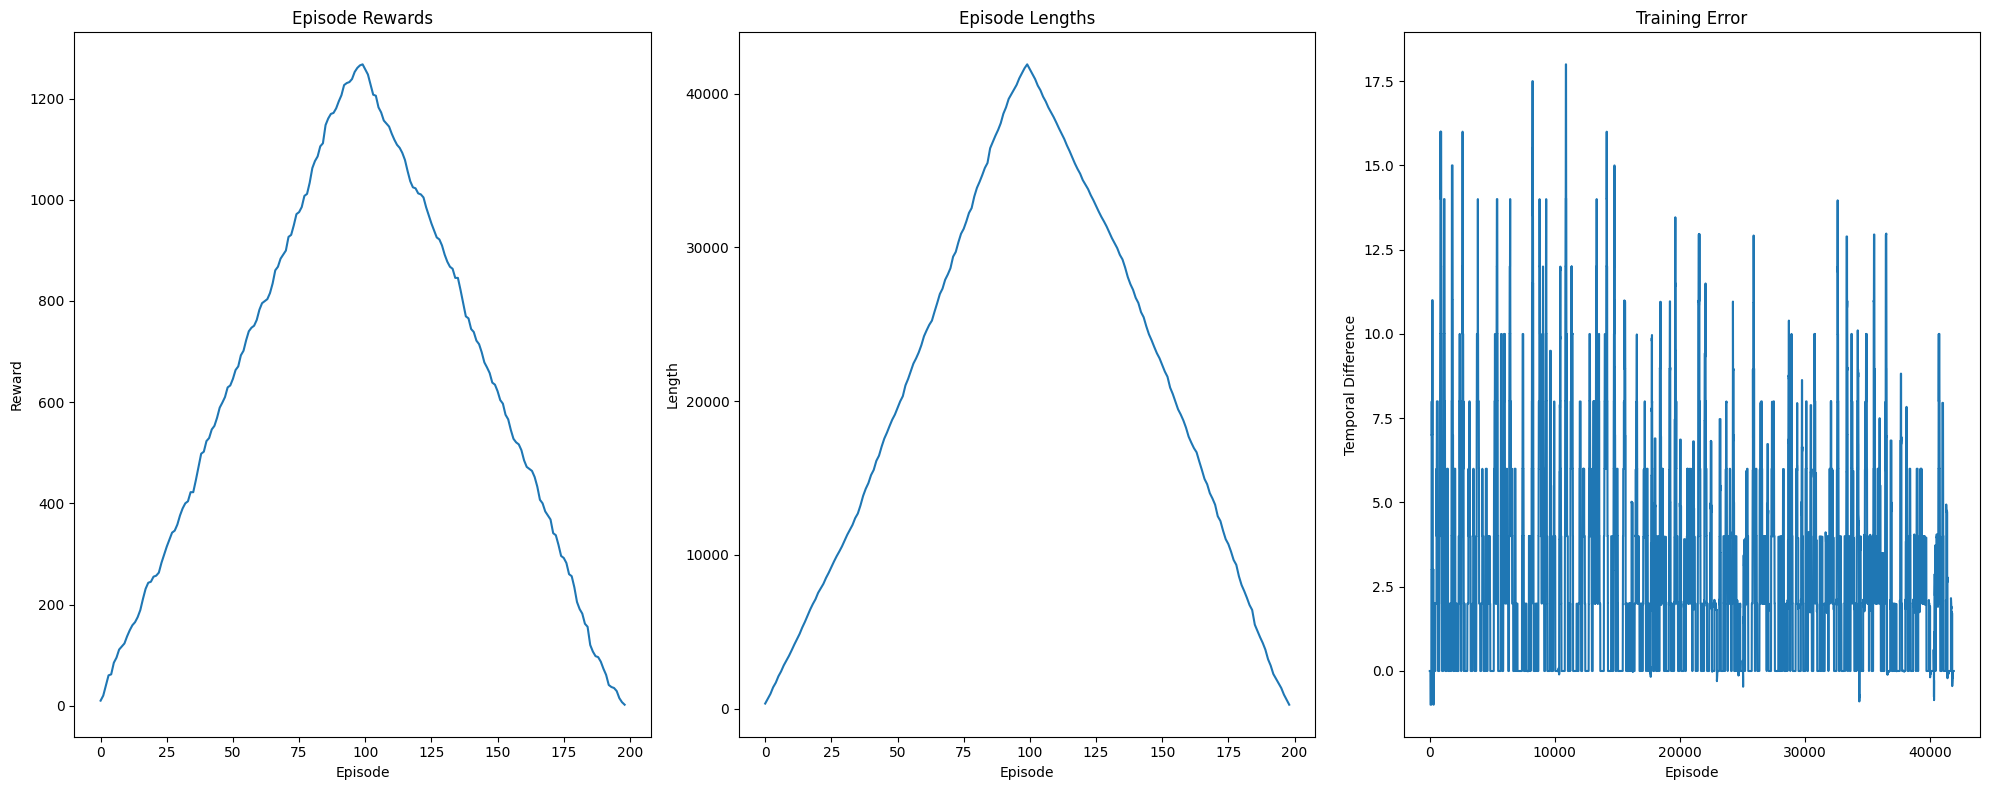

In [12]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
axs[2].set_title("Training Error")
axs[2].set_xlabel("Episode")
axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

In [13]:
env.close()

### Registrazione episodi

In [14]:
num_eval_episodes = 10

env = gym.make("ALE/Qbert-ram-v5", render_mode="rgb_array")
env =  QbertObservationWrapperTuple(env)
env = RecordVideo(env, video_folder="videos_first", name_prefix="eval",
                  episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)

In [15]:
for episode_num in range(num_eval_episodes):
    obs, info = env.reset()
    rewardFunction = RewardFunction(obs[0])
    obs = obs[1]
    done = False

    while not done:
        action = agent.get_action(obs, False)
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = rewardFunction.calculate_reward(next_obs, reward)
        obs =  next_obs[1]

        done = terminated or truncated
env.close()

In [16]:
print(f'Episode time taken: {env.time_queue}')
print(f'Episode total rewards: {env.return_queue}')
print(f'Episode lengths: {env.length_queue}')
print("Training terminato")

Episode time taken: deque([1.068891, 1.058186, 0.970074, 1.06947, 0.971555, 1.530847, 1.121135, 0.983344, 1.265392, 1.108461], maxlen=10)
Episode total rewards: deque([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], maxlen=10)
Episode lengths: deque([1038, 1038, 1038, 1038, 1038, 1038, 1038, 1038, 1038, 1038], maxlen=10)
Training terminato
